# Proyecto Final · Módulo 4  
## Estadística y Probabilidad para Data Science orientada a Machine Learning

## Limpieza de Datos


### Extraccion y carga de DT

In [55]:
# Importar librerías necesarias para el análisis de datos y visualización
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [2]:
# Definir rutas de los archivos CSV y cargar los datos
RUTA = {
    "order_items": "../data/raw/order_items.csv",
    "product_catalog": "../data/raw/product_catalog.csv"
    }
    
order_items = pd.read_csv(RUTA["order_items"])
product_catalog =pd.read_csv(RUTA["product_catalog"])

In [3]:
# Unir los datos de order_items y product_catalog y reorganizar las columnas
df_limpio = pd.merge(order_items, product_catalog, on='product_id', how='left')

cols_original = df_limpio.columns.tolist()

# Nuevo orden de las columnas
nuevo_orden = [
    'order_id','product_id','product_name','product_category',
    'product_subcategory','brand','supplier'
] + [c for c in cols_original if c not in [
    'order_id','product_id','product_name','product_category',
    'product_subcategory','brand','supplier'
]]

df_limpio = df_limpio[nuevo_orden]

print(df_limpio.columns.tolist())

['order_id', 'product_id', 'product_name', 'product_category', 'product_subcategory', 'brand', 'supplier', 'quantity', 'unit_price_x', 'discount_percentage', 'discount_amount', 'gross_sales', 'tax_amount', 'shipping_cost', 'net_sales', 'product_cost_x', 'profit', 'unit_price_y', 'product_cost_y', 'product_rating']


### Revision de datos

In [4]:
df_limpio.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 397569 entries, 0 to 397568
Data columns (total 20 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   order_id             397569 non-null  object 
 1   product_id           397569 non-null  object 
 2   product_name         397569 non-null  object 
 3   product_category     397569 non-null  object 
 4   product_subcategory  397569 non-null  object 
 5   brand                397569 non-null  object 
 6   supplier             397569 non-null  object 
 7   quantity             397569 non-null  int64  
 8   unit_price_x         397569 non-null  float64
 9   discount_percentage  397569 non-null  float64
 10  discount_amount      397569 non-null  float64
 11  gross_sales          397569 non-null  float64
 12  tax_amount           397569 non-null  float64
 13  shipping_cost        397569 non-null  float64
 14  net_sales            397569 non-null  float64
 15  product_cost_x   

In [5]:
df_limpio.isnull().sum()

order_id               0
product_id             0
product_name           0
product_category       0
product_subcategory    0
brand                  0
supplier               0
quantity               0
unit_price_x           0
discount_percentage    0
discount_amount        0
gross_sales            0
tax_amount             0
shipping_cost          0
net_sales              0
product_cost_x         0
profit                 0
unit_price_y           0
product_cost_y         0
product_rating         0
dtype: int64

In [6]:
df_limpio.shape

(397569, 20)

In [7]:
df_limpio.duplicated().sum()

np.int64(0)

In [8]:
df_limpio.dtypes

order_id                object
product_id              object
product_name            object
product_category        object
product_subcategory     object
brand                   object
supplier                object
quantity                 int64
unit_price_x           float64
discount_percentage    float64
discount_amount        float64
gross_sales            float64
tax_amount             float64
shipping_cost          float64
net_sales              float64
product_cost_x         float64
profit                 float64
unit_price_y           float64
product_cost_y         float64
product_rating         float64
dtype: object

### Comparación de columnas duplicadas (`_x` / `_y`)

Al unir `order_items` con `product_catalog` aparecieron columnas repetidas (`unit_price_x/_y`, `product_cost_x/_y`). Antes de decidir qué hacer con ellas, se verifica si son realmente iguales o si una depende de la otra.

In [9]:
print("\nComparación de precios unitarios:")
print("-" * 40)
print((df_limpio["unit_price_x"] == df_limpio["unit_price_y"]).value_counts()) # True    397569

print("\nComparación de costos de producto:")
print("-" * 40)
print((df_limpio["product_cost_x"] == df_limpio["product_cost_y"]).value_counts()) # False    231956 | True     165613
                                                                                   # Conclusión: no son columnas duplicadas.


Comparación de precios unitarios:
----------------------------------------
True    397569
Name: count, dtype: int64

Comparación de costos de producto:
----------------------------------------
False    231956
True     165613
Name: count, dtype: int64


In [10]:
print("\nComparación de costos de producto (detalle):")
print("-" * 50)
print((df_limpio["product_cost_x"] == df_limpio["product_cost_y"]))
print(
    (df_limpio["product_cost_x"] == df_limpio["product_cost_y"])
    .value_counts()
)


Comparación de costos de producto (detalle):
--------------------------------------------------
0         False
1         False
2         False
3         False
4         False
          ...  
397564    False
397565    False
397566    False
397567     True
397568    False
Length: 397569, dtype: bool
False    231956
True     165613
Name: count, dtype: int64


In [11]:
# Comprobar si product_cost_x depende de quantity
print("Relación entre costo y cantidad:")
print("-" * 40)

print(
    (
        df_limpio["product_cost_x"]
        ==
        df_limpio["product_cost_y"] * df_limpio["quantity"]
    ).value_counts()
)
# Aparecen algunos False debido a la precisión de los números float
# True     368799
# False     28770

Relación entre costo y cantidad:
----------------------------------------
True     368799
False     28770
Name: count, dtype: int64


In [12]:
# Repetir la comprobación usando tolerancia numérica
comparacion = np.isclose(
    df_limpio["product_cost_x"],
    df_limpio["product_cost_y"] * df_limpio["quantity"]
)

print(pd.Series(comparacion).value_counts())
# Pues sí, la relación se cumple para todas las filas considerando pequeñas diferencias de precisión numérica.
# True    397569
# Name: count, dtype: int64


True    397569
Name: count, dtype: int64


In [13]:
# Verificar una fila manualmente
num_fila = 0

print("Verificación manual de la fila")
print("=" * 75)
print(df_limpio.loc[num_fila])
print("=" * 75)

print(df_limpio.columns.tolist())
print("-" * 75)

fila = df_limpio.loc[num_fila]

print("quantity:", fila["quantity"])
print("product_cost_x:", fila["product_cost_x"])
print("product_cost_y:", fila["product_cost_y"])

print(
    "product_cost_y * quantity:",
    fila["product_cost_y"] * fila["quantity"]
)

Verificación manual de la fila
order_id                                                      ORD-301242
product_id                                                   PROD-000738
product_name           Garmin Total client-driven task-force Medical ...
product_category                                       Health & Wellness
product_subcategory                                      Medical Devices
brand                                                             Garmin
supplier                                                  Euro Logistics
quantity                                                               2
unit_price_x                                                       244.4
discount_percentage                                             0.339607
discount_amount                                                    166.0
gross_sales                                                        488.8
tax_amount                                                          22.6
shipping_cost       

### Filas duplicadas por combinación pedido + producto

In [14]:
# Cuenta las filas donde se repite la combinación pedido + producto.
# No significa que sean filas completamente duplicadas.
duplicados = df_limpio.duplicated(["order_id", "product_id"]).sum()

print("Duplicados order_id + product_id:", duplicados)


filas_repetidas = df_limpio.duplicated(
    ["order_id", "product_id"],
    keep=False
).sum()

print("Filas involucradas en repeticiones:", filas_repetidas)

# Selecciona todas las filas donde se repite pedido + producto.
ejemplos = df_limpio[
    df_limpio.duplicated(["order_id", "product_id"], keep=False) # keep=False permite mostrar todas las filas de cada repetición.
].sort_values(["order_id", "product_id"])

# Muestrar los primeros 10 ejemplos.
ejemplos[
    [
        "order_id",
        "product_id",
        "product_name",
        "quantity",
        "unit_price_x",
        "discount_percentage",
        "gross_sales",
        "profit"
    ]
].head(10)


Duplicados order_id + product_id: 87
Filas involucradas en repeticiones: 174


,order_id,product_id,product_name,quantity,unit_price_x,discount_percentage,gross_sales,profit
292639,ORD-116240,PROD-001079,General Mills Triple-buffered client-server wo...,4,42.15,0.043355,168.60,120.54
364770,ORD-116240,PROD-001079,General Mills Triple-buffered client-server wo...,1,42.15,0.123642,42.15,26.52
101373,ORD-124215,PROD-000044,LG Stand-alone logistical circuit Smart Watches,4,863.97,0.144428,3455.88,1147.28
138789,ORD-124215,PROD-000044,LG Stand-alone logistical circuit Smart Watches,1,863.97,0.096381,863.97,424.92
295982,ORD-135029,PROD-000354,Walmart Virtual intangible portal Decor,2,256.59,0.160479,513.18,160.67
393368,ORD-135029,PROD-000354,Walmart Virtual intangible portal Decor,1,256.59,0.187609,256.59,77.19
148721,ORD-142265,PROD-000252,Estée Lauder Visionary optimal standardization...,2,56.89,0.201220,113.78,64.61
280218,ORD-142265,PROD-000252,Estée Lauder Visionary optimal standardization...,3,56.89,0.078282,170.67,111.17
132913,ORD-172413,PROD-000648,Thule Digitized disintermediate benchmark Main...,1,213.86,0.176749,213.86,73.61
256204,ORD-172413,PROD-000648,Thule Digitized disintermediate benchmark Main...,2,213.86,0.072253,427.72,152.80


### Renombrar columnas

In [15]:
# Renombrar columnas y eliminar columnas innecesarias
df_limpio = df_limpio.rename(columns={
    "unit_price_x": "unit_price",
    "product_cost_x": "product_cost_total",
    "product_cost_y": "product_cost",
})

df_limpio = df_limpio.drop(columns=["unit_price_y"])

print("\nColumnas después de la limpieza:")
print(df_limpio.columns.tolist())
df_limpio.head()

# df_limpio


Columnas después de la limpieza:
['order_id', 'product_id', 'product_name', 'product_category', 'product_subcategory', 'brand', 'supplier', 'quantity', 'unit_price', 'discount_percentage', 'discount_amount', 'gross_sales', 'tax_amount', 'shipping_cost', 'net_sales', 'product_cost_total', 'profit', 'product_cost', 'product_rating']


,order_id,product_id,product_name,product_category,product_subcategory,brand,supplier,quantity,unit_price,discount_percentage,discount_amount,gross_sales,tax_amount,shipping_cost,net_sales,product_cost_total,profit,product_cost,product_rating
0,ORD-301242,PROD-000738,Garmin Total client-driven task-force Medical ...,Health & Wellness,Medical Devices,Garmin,Euro Logistics,2,244.40,0.339607,166.00,488.80,22.60,6.48,351.88,173.28,172.12,86.64,4.8
1,ORD-301242,PROD-000181,Tommy Hilfiger Open-architected full-range foc...,Fashion,Shoes,Tommy Hilfiger,Pacific Trade,3,287.13,0.362076,311.89,861.39,38.47,5.55,593.52,415.05,172.92,138.35,3.0
2,ORD-773460,PROD-000973,Swarovski Re-engineered discrete monitoring Ea...,Jewelry,Earrings,Swarovski,MultiSource,4,754.80,0.468300,1413.89,3019.20,305.01,9.00,1919.32,1976.16,-65.84,494.04,3.5
3,ORD-773460,PROD-000268,NARS Enterprise-wide actuating firmware Fragra...,Beauty & Personal Care,Fragrances,NARS,Global Trade,4,31.36,0.336182,42.17,125.44,15.82,0.00,99.09,55.72,43.37,13.93,4.0
4,ORD-449374,PROD-001040,Mars Multi-tiered homogeneous artificial intel...,Grocery,Pantry Staples,Mars,Asian Manufacturing,3,6.31,0.089678,1.70,18.93,1.21,0.98,19.42,5.91,12.53,1.97,3.0


In [16]:
df_limpio.dtypes

order_id                object
product_id              object
product_name            object
product_category        object
product_subcategory     object
brand                   object
supplier                object
quantity                 int64
unit_price             float64
discount_percentage    float64
discount_amount        float64
gross_sales            float64
tax_amount             float64
shipping_cost          float64
net_sales              float64
product_cost_total     float64
profit                 float64
product_cost           float64
product_rating         float64
dtype: object

Lo que pudimos encontrar en esta fase inicial de revision, es que el dataset esta bastante limpio para su manipulacion, las columnas estan con sus tipos de datos correctos, no hay valores nulos/faltantes y tampoco existen duplicados.

Cabe a destacar que la metodología del proyecto debe partir de las variables proporcionadas y documentadas por el dataset, y cualquier variable nueva que creemos debe identificarse claramente como una variable derivada.

---


In [17]:
#Agrupacion de la columnas segun si tipo de datos para su analisis estadistico y visualizacion
col_num = df_limpio.select_dtypes(include=[np.number]).columns.tolist()
col_cat = df_limpio.select_dtypes(include=[object]).columns.tolist()

In [34]:
print("\nAnalisis descriptivo")
print("-" * 50)
val_des=df_limpio[col_num].describe().T
val_des["skew"] = df_limpio[col_num].skew()
val_des["kurtosis"]= df_limpio[col_num].kurtosis()
val_des["cv_porc"]=(val_des["std"]/val_des["mean"]*100).round(1)

print(val_des[["mean", "std", "skew", "kurtosis","cv_porc","min","max"]])


Analisis descriptivo
--------------------------------------------------
                           mean         std      skew   kurtosis  cv_porc  \
quantity               2.118792    1.196276  0.804363  -0.377967     56.5   
unit_price           245.189134  251.035134  1.989665   4.361939    102.4   
discount_percentage    0.147059    0.129986  1.185062   1.251354     88.4   
discount_amount       89.667873  190.637796  5.425945  43.847792    212.6   
gross_sales          519.013550  676.800478  3.213136  14.614023    130.4   
tax_amount            46.183642   71.072019  4.629266  34.516000    153.9   
shipping_cost          8.409010    6.777155  1.182646   0.904647     80.6   
net_sales            483.938328  615.430188  3.329574  16.503121    127.2   
product_cost_total   267.520046  394.773555  3.696407  19.686416    147.6   
profit               208.009273  266.477677  3.331977  17.928617    128.1   
product_cost         126.391080  150.020177  2.375037   6.650620    118.7   
pro


Visualizacion de distribucion de la variable descuento amount
--------------------------------------------------


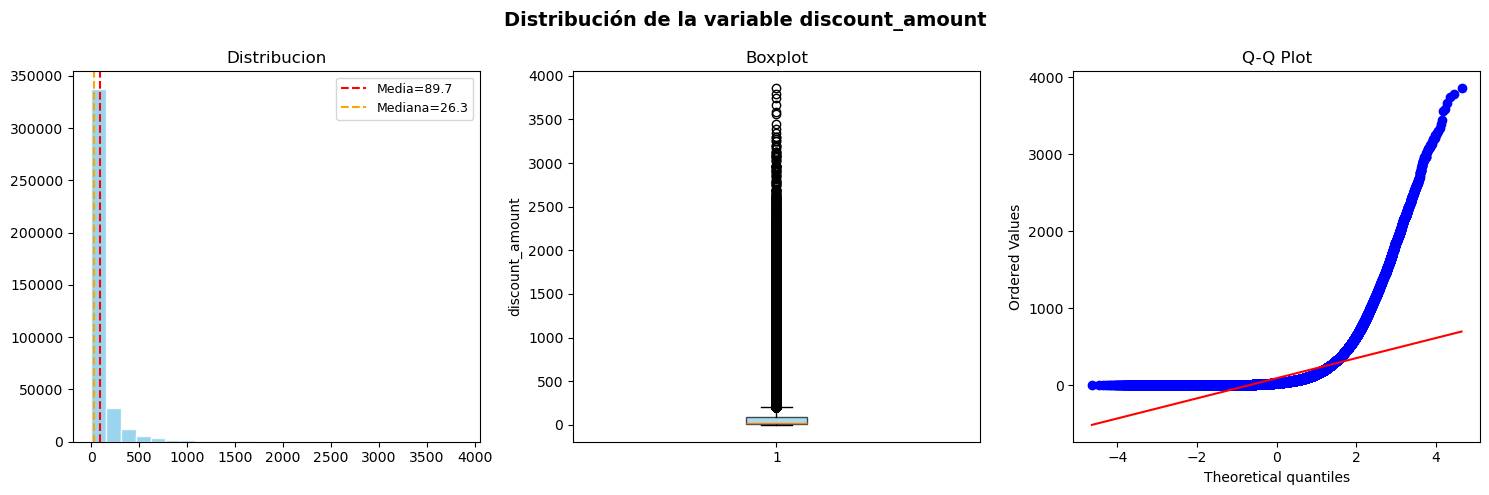

In [56]:
print("\nVisualizacion de distribucion de la variable descuento amount")
print("-" * 50)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle("Distribución de la variable discount_amount", fontsize=14, fontweight='bold')

#Hist
axes[0].hist(df_limpio['discount_amount'], bins=25, color='skyblue', edgecolor='white', alpha=0.85)
axes[0].axvline(df_limpio['discount_amount'].mean(), color='red', linestyle="--",  label= f"Media={df_limpio['discount_amount'].mean() :.1f}")
axes[0].axvline(df_limpio['discount_amount'].median(), color='orange', linestyle="--", label= f"Mediana={df_limpio['discount_amount'].median() :.1f}")
axes[0].set_title('Distribucion')
axes[0].legend(fontsize=9)


#Box
axes[1].boxplot(df_limpio['discount_amount'], vert=True, patch_artist=True, boxprops=dict(facecolor='skyblue', alpha=0.70))
axes[1].set_title('Boxplot')
axes[1].set_ylabel('discount_amount')

#QQ
stats.probplot(df_limpio['discount_amount'], plot=axes[2])
axes[2].set_title('Q-Q Plot')

plt.tight_layout()
plt. show()

